In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [7]:
files = ["fiducial", 'kickflag_1', 'bhflag_3']
labels = ["Disberg+2025", "Hobbs+05", "Disberg+2025\n(No fallback scaling)"]    
colours = ["#333", "tab:orange", "darkgreen"]

In [8]:
pops, data = helpers.load_postprocessed_pops(files, labels, colours)

In [9]:
linestyles = ["-", "-", ":"]
for i, pop in enumerate(pops):
    pop.linestyle = linestyles[i]

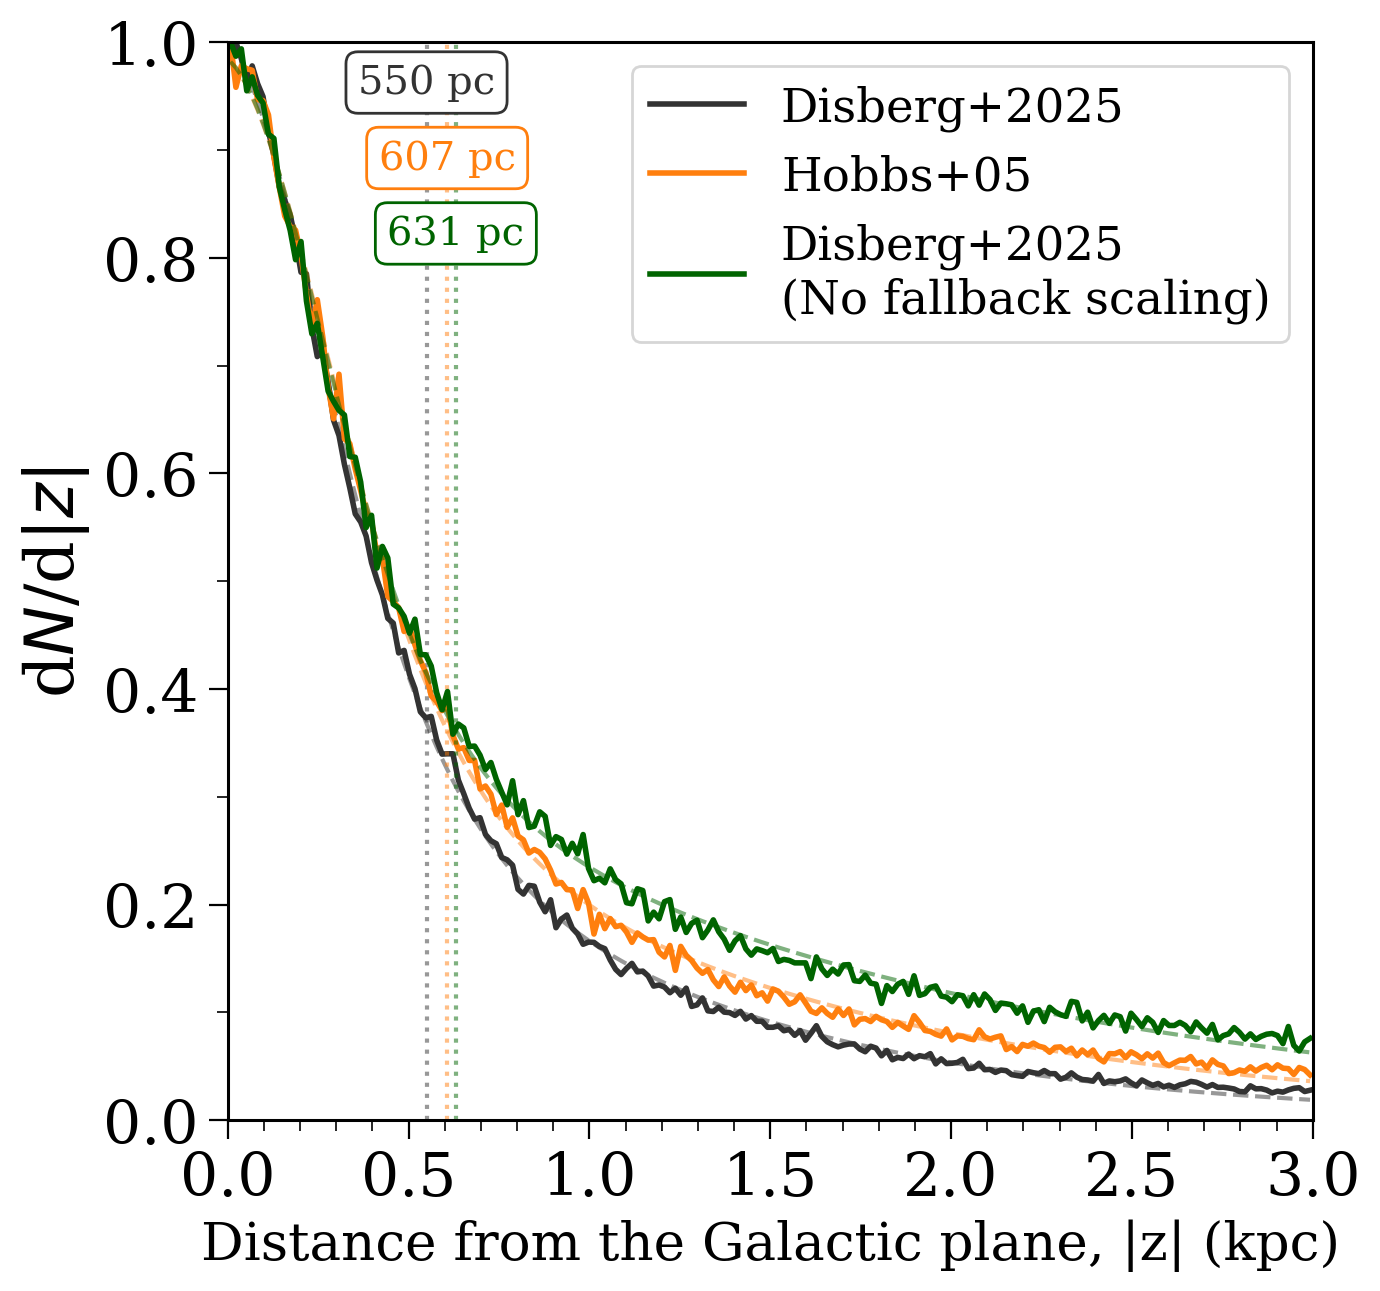

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for pop, loc in zip(pops, [0.98 - 0.07 * 0, 0.98 - 0.07 * 1, 0.98 - 0.07 * 2]):

    plotting.estimate_scale_height(
        z=data[pop.label]["pos"]["BH"][:, 2],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=loc,
        R=None,
    )

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_kicks.pdf", format="pdf", bbox_inches='tight')

plt.show()

In [18]:
masses = {}

for pop in pops:
    mass = {
        "BH": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
        )),
        "NS": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
        )),
    }
    mass["CO"] = np.concatenate((mass["NS"], mass["BH"]))
    masses[pop.label] = mass

In [22]:
print("Average BH masses:")
print("------------------")

for pop in pops:
    mass = masses[pop.label]

    average_escaped_BH_mass = np.mean(mass["BH"][kinematics[pop.label]["escaped"]["BH"]])
    average_bound_BH_mass = np.mean(mass["BH"][~kinematics[pop.label]["escaped"]["BH"]])

    avg_bound_BH_close_to_disc = np.mean(mass["BH"][(
        ~kinematics[pop.label]["escaped"]["BH"] &
        (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) < 1)
    )])

    avg_bound_BH_far_from_disc = np.mean(mass["BH"][(
        ~kinematics[pop.label]["escaped"]["BH"] &
        (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) >= 1)
    )])

    print(f"{pop.label}")
    print(f"  Escaped: {average_escaped_BH_mass:.1f} Msun")
    print(f"  Bound:   {average_bound_BH_mass:.1f} Msun")
    print(f"    Close to disc (<1 kpc):  {avg_bound_BH_close_to_disc:.1f} Msun")
    print(f"    Far from disc (>=1 kpc): {avg_bound_BH_far_from_disc:.1f} Msun")
    print()

Average BH masses:
------------------
Disberg+2025
  Escaped: 5.2 Msun
  Bound:   9.3 Msun
    Close to disc (<1 kpc):  10.0 Msun
    Far from disc (>=1 kpc): 7.7 Msun

Disberg+2025
(no fallback scaling)
  Escaped: 8.8 Msun
  Bound:   8.2 Msun
    Close to disc (<1 kpc):  7.6 Msun
    Far from disc (>=1 kpc): 8.7 Msun



In [10]:
z_range = np.geomspace(0.1, 10, 1000)

init_bh_z = np.concatenate((
    pops[0].initial_galaxy.z[pops[0].final_bpp["kstar_1"] == 14],
    pops[0].initial_galaxy.z[pops[0].final_bpp["kstar_2"] == 14]
))
init_abs_z = np.abs(init_bh_z.to(u.kpc).value)

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(data[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value)
            for pop in pops] + [init_abs_z],
    bh_masses=[masses[pop.label]["BH"] for pop in pops] + [masses[pops[0].label]["BH"]],
    z_range=z_range,
    window_width=0.1
)

AttributeError: 'DummyPop' object has no attribute 'initial_galaxy'

NameError: name 'z_range' is not defined

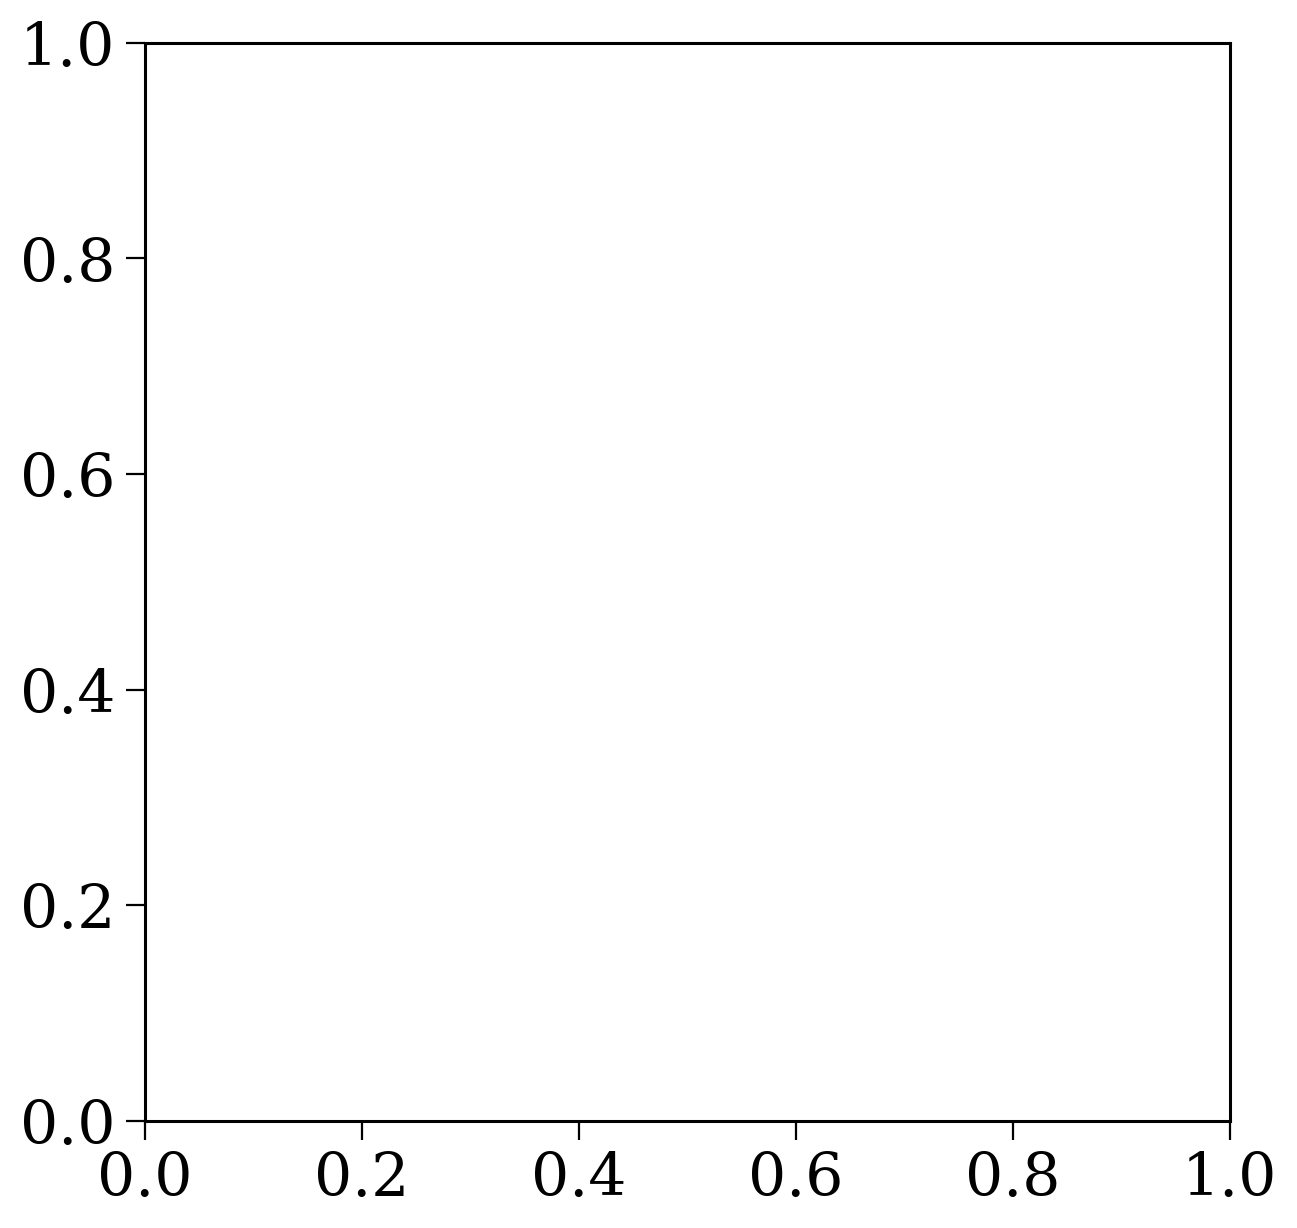

In [14]:
fig, ax = plt.subplots(figsize=(7, 7))

for i, pop in enumerate(pops):
    ax.plot(z_range, mean_masses[i], label=pop.label, color=pop.colour, linestyle=pop.linestyle)
ax.plot(z_range[z_range < 3], mean_masses[-1][z_range < 3],
        label="Initial BHs", color="black")

ax.set(
    xscale='log',
    xlabel=r'Absolute Galactic Height, $|z|$ (kpc)',
    ylabel=r'Average BH Mass, $\langle m_{\rm BH} \rangle$ (M$_\odot$)',
    xlim=(0.1, 10),
)

ax.legend()

ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.5))

plt.show()